Transforming the play by play data to make it into a good form for modeling

In [174]:
import pandas as pd
import os

# Load the first dataset from the nba_pbp_2024_25 directory
data_dir = 'nba_pbp_2024_25'
files = os.listdir(data_dir)
first_file = [f for f in files if f.endswith('.parquet')][0]    
test_pbp = pd.read_parquet(os.path.join(data_dir, first_file))
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
test_pbp.iloc[10:20]

,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,gameId
10,15,PT10M57.00S,1,1610612738,BOS,1627759,Brown,J. Brown,0,0,0,,0,,,0,h,Brown Bad Pass Turnover (P1.T1),Turnover,Bad Pass,1,0,11,0022400001
11,15,PT10M57.00S,1,1610612737,ATL,1630700,Daniels,D. Daniels,0,0,0,,0,,,0,v,Daniels STEAL (1 STL),,,1,0,12,0022400001
12,17,PT10M55.00S,1,1610612737,ATL,1630700,Daniels,D. Daniels,0,0,0,,0,,,0,v,Daniels Bad Pass Turnover (P1.T2),Turnover,Bad Pass,1,0,13,0022400001
13,17,PT10M55.00S,1,1610612738,BOS,1628401,White,D. White,0,0,0,,0,,,0,h,White STEAL (1 STL),,,1,0,14,0022400001
14,19,PT10M54.00S,1,1610612738,BOS,1628401,White,D. White,0,0,0,,0,,,0,h,White Bad Pass Turnover (P1.T2),Turnover,Bad Pass,1,0,15,0022400001
15,19,PT10M54.00S,1,1610612737,ATL,1630700,Daniels,D. Daniels,0,0,0,,0,,,0,v,Daniels STEAL (2 STL),,,1,0,16,0022400001
16,21,PT10M50.00S,1,1610612737,ATL,1630552,Johnson,J. Johnson,157,203,26,Made,1,0,3,3,v,Johnson 26' 3PT Jump Shot (3 PTS) (Wallace 1 AST),Made Shot,Jump Shot,1,3,17,0022400001
17,23,PT10M35.00S,1,1610612738,BOS,1627759,Brown,J. Brown,102,253,27,Made,1,3,3,6,h,Brown 27' 3PT Pullup Jump Shot (3 PTS) (White 1 AST),Made Shot,Pullup Jump shot,1,3,18,0022400001
18,24,PT10M24.00S,1,1610612738,BOS,1627759,Brown,J. Brown,0,0,0,,0,,,0,h,Brown S.FOUL (P1.T1) (R.Acosta),Foul,Shooting,1,0,19,0022400001
19,27,PT10M24.00S,1,1610612737,ATL,203991,Capela,C. Capela,0,0,0,,0,,,0,v,MISS Capela Free Throw 1 of 2,Free Throw,Free Throw 1 of 2,1,0,20,0022400001


In [175]:
test_pbp.columns

Index(['actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId',
       'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance',
       'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal',
       'location', 'description', 'actionType', 'subType', 'videoAvailable',
       'shotValue', 'actionId', 'gameId'],
      dtype='object')

In [176]:
# Evaluate how often shotResult is not null and score is null
sum(test_pbp['shotResult'].notnull() & (test_pbp['scoreHome'].isnull() | test_pbp['scoreAway'].isnull()))

0

Because the score is always present when there is a scoring play, we can safely fill non-present scores with the most recent available score. (BC the score hasn't changed since it was last displayed)

In [177]:
test_pbp_colsub = test_pbp[['gameId', 'actionId', 'clock', 'period', 'teamId', 'scoreHome', 'scoreAway', 'pointsTotal', 'description']].copy()
test_pbp_colsub.head()

,gameId,actionId,clock,period,teamId,scoreHome,scoreAway,pointsTotal,description
0,0022400001,1,PT12M00.00S,1,0,0,0,0,Start of 1st Period (7:11 PM EST)
1,0022400001,2,PT12M00.00S,1,1610612738,,,0,Jump Ball Horford vs. Capela: Tip to Wallace
2,0022400001,3,PT11M43.00S,1,1610612737,,,0,MISS Risacher 27' 3PT Jump Shot
3,0022400001,4,PT11M43.00S,1,1610612738,,,0,Tatum BLOCK (1 BLK)
4,0022400001,5,PT11M42.00S,1,1610612737,,,0,Risacher REBOUND (Off:1 Def:0)


In [178]:
# Note: This correction assumes the score is correct on every scoring play

# Convert scoreHome and scoreAway to numeric, handling empty strings
test_pbp_colsub.loc[:, 'scoreHome'] = pd.to_numeric(test_pbp_colsub['scoreHome'], errors='coerce')
test_pbp_colsub.loc[:, 'scoreAway'] = pd.to_numeric(test_pbp_colsub['scoreAway'], errors='coerce')

# Forward fill to inherit scores from previous actionId
test_pbp_colsub.loc[:, 'scoreHome'] = test_pbp_colsub['scoreHome'].fillna(method='ffill')
test_pbp_colsub.loc[:, 'scoreAway'] = test_pbp_colsub['scoreAway'].fillna(method='ffill')
test_pbp_colsub.loc[:, 'pointsTotal'] = test_pbp_colsub['scoreHome'] + test_pbp_colsub['scoreAway']
test_pbp_colsub.head(20)

C:\Users\rajak\AppData\Local\Temp\ipykernel_14528\382453865.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_pbp_colsub.loc[:, 'scoreHome'] = test_pbp_colsub['scoreHome'].fillna(method='ffill')
C:\Users\rajak\AppData\Local\Temp\ipykernel_14528\382453865.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_pbp_colsub.loc[:, 'scoreHome'] = test_pbp_colsub['scoreHome'].fillna(method='ffill')
C:\Users\rajak\AppData\Local\Temp\ipykernel_14528\382453865.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_pbp_colsub.loc[:, 'scoreAway'] = test_pbp_colsub['scoreAway'].fillna(method='ffil

,gameId,actionId,clock,period,teamId,scoreHome,scoreAway,pointsTotal,description
0,0022400001,1,PT12M00.00S,1,0,0.0,0.0,0.0,Start of 1st Period (7:11 PM EST)
1,0022400001,2,PT12M00.00S,1,1610612738,0.0,0.0,0.0,Jump Ball Horford vs. Capela: Tip to Wallace
2,0022400001,3,PT11M43.00S,1,1610612737,0.0,0.0,0.0,MISS Risacher 27' 3PT Jump Shot
3,0022400001,4,PT11M43.00S,1,1610612738,0.0,0.0,0.0,Tatum BLOCK (1 BLK)
4,0022400001,5,PT11M42.00S,1,1610612737,0.0,0.0,0.0,Risacher REBOUND (Off:1 Def:0)
5,0022400001,6,PT11M38.00S,1,1610612737,0.0,0.0,0.0,MISS Johnson 14' Driving Floating Bank Jump Shot
6,0022400001,7,PT11M37.00S,1,1610612738,0.0,0.0,0.0,Horford REBOUND (Off:0 Def:1)
7,0022400001,8,PT11M24.00S,1,1610612738,0.0,0.0,0.0,MISS White 28' 3PT Jump Shot
8,0022400001,9,PT11M22.00S,1,1610612737,0.0,0.0,0.0,Johnson REBOUND (Off:0 Def:1)
9,0022400001,10,PT11M17.00S,1,1610612737,0.0,0.0,0.0,Johnson Traveling Turnover (P1.T1)


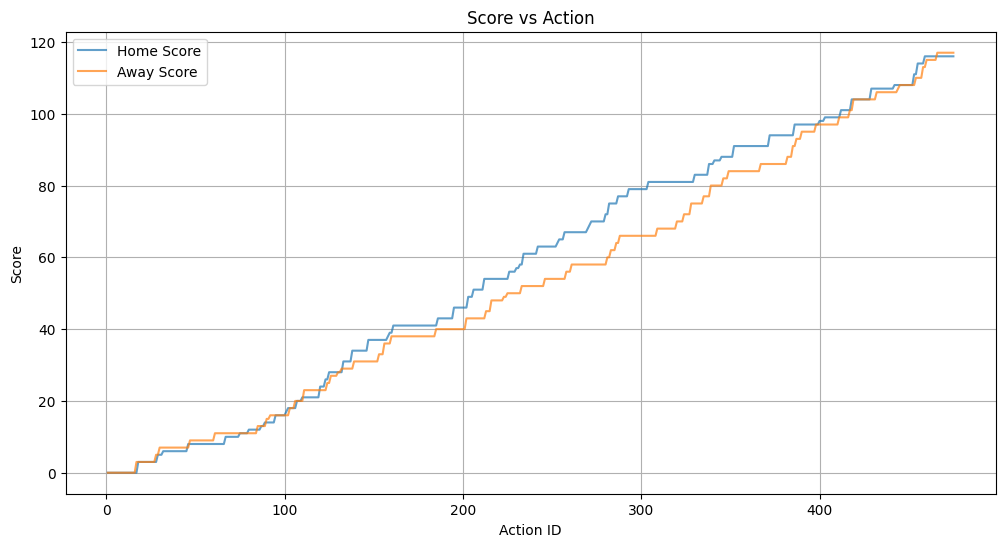

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test_pbp_colsub['actionId'], test_pbp_colsub['scoreHome'], label='Home Score', alpha=0.7)
plt.plot(test_pbp_colsub['actionId'], test_pbp_colsub['scoreAway'], label='Away Score', alpha=0.7)
plt.xlabel('Action ID')
plt.ylabel('Score')
plt.title('Score vs Action')
plt.legend()
plt.grid(True)
plt.show()

In [180]:
# Convert clock format from PT10M24.00S to seconds
def clock_to_seconds(clock_str):
    # Extract minutes and seconds from PT format
    time_str = clock_str.replace('PT', '').replace('S', '')
    parts = time_str.split('M')
    minutes = int(parts[0])
    seconds = float(parts[1])
    return minutes * 60 + seconds
    # Convert to time remaining in the game
    # Each period is 720 seconds (12 minutes), so we calculate remaining time based on period and clock
test_pbp_colsub.loc[:,'secondsLeft'] = (4 - test_pbp_colsub['period']) * 720 + test_pbp_colsub['clock'].apply(clock_to_seconds)

test_pbp_colsub.head()

,gameId,actionId,clock,period,teamId,scoreHome,scoreAway,pointsTotal,description,secondsLeft
0,0022400001,1,PT12M00.00S,1,0,0.0,0.0,0.0,Start of 1st Period (7:11 PM EST),2880.0
1,0022400001,2,PT12M00.00S,1,1610612738,0.0,0.0,0.0,Jump Ball Horford vs. Capela: Tip to Wallace,2880.0
2,0022400001,3,PT11M43.00S,1,1610612737,0.0,0.0,0.0,MISS Risacher 27' 3PT Jump Shot,2863.0
3,0022400001,4,PT11M43.00S,1,1610612738,0.0,0.0,0.0,Tatum BLOCK (1 BLK),2863.0
4,0022400001,5,PT11M42.00S,1,1610612737,0.0,0.0,0.0,Risacher REBOUND (Off:1 Def:0),2862.0


In [181]:
test_pbp_colsub.drop(["clock", "teamId"], axis =1, inplace=True)

In [182]:
test_pbp_colsub.head()

,gameId,actionId,period,scoreHome,scoreAway,pointsTotal,description,secondsLeft
0,0022400001,1,1,0.0,0.0,0.0,Start of 1st Period (7:11 PM EST),2880.0
1,0022400001,2,1,0.0,0.0,0.0,Jump Ball Horford vs. Capela: Tip to Wallace,2880.0
2,0022400001,3,1,0.0,0.0,0.0,MISS Risacher 27' 3PT Jump Shot,2863.0
3,0022400001,4,1,0.0,0.0,0.0,Tatum BLOCK (1 BLK),2863.0
4,0022400001,5,1,0.0,0.0,0.0,Risacher REBOUND (Off:1 Def:0),2862.0


Add in 2024-2025 pbp data

In [183]:
gamelog_24_25 = pd.read_parquet("nba_gamelog/gamelog_2024-25.parquet")
gamelog_24_25.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON
0,22024,1610612738,BOS,Boston Celtics,0022400061,2024-10-22,BOS vs. NYK,W,240,48,95,0.505,29,61,0.475,7,8,0.875,11,29,40,33,6,3,4,15,132,23,1,2024-25
1,22024,1610612750,MIN,Minnesota Timberwolves,0022400062,2024-10-22,MIN @ LAL,L,240,35,85,0.412,13,41,0.317,20,27,0.741,12,35,47,17,4,1,16,22,103,-7,1,2024-25
2,22024,1610612747,LAL,Los Angeles Lakers,0022400062,2024-10-22,LAL vs. MIN,W,240,42,95,0.442,5,30,0.167,21,25,0.840,15,31,46,22,7,8,7,22,110,7,1,2024-25
3,22024,1610612752,NYK,New York Knicks,0022400061,2024-10-22,NYK @ BOS,L,240,43,78,0.551,11,30,0.367,12,16,0.750,5,29,34,20,2,3,12,12,109,-23,1,2024-25
4,22024,1610612744,GSW,Golden State Warriors,0022400072,2024-10-23,GSW @ POR,W,240,48,93,0.516,20,48,0.417,24,30,0.800,15,42,57,38,13,5,18,27,140,36,1,2024-25


In [184]:
# Convert gamelog_24_25 columns to camel case from all caps with underscore separation
gamelog_24_25.columns = gamelog_24_25.columns.str.lower().str.replace(r'_(\w)', lambda m: m.group(1).upper(), regex=True)
gamelog_24_25.columns

Index(['seasonId', 'teamId', 'teamAbbreviation', 'teamName', 'gameId',
       'gameDate', 'matchup', 'wl', 'min', 'fgm', 'fga', 'fgPct', 'fg3m',
       'fg3a', 'fg3Pct', 'ftm', 'fta', 'ftPct', 'oreb', 'dreb', 'reb', 'ast',
       'stl', 'blk', 'tov', 'pf', 'pts', 'plusMinus', 'videoAvailable',
       'season'],
      dtype='object')

In [185]:
test_pbp_colsub.columns

Index(['gameId', 'actionId', 'period', 'scoreHome', 'scoreAway', 'pointsTotal',
       'description', 'secondsLeft'],
      dtype='object')

In [186]:
test_pbp = pd.merge(test_pbp_colsub, gamelog_24_25[['season', 'gameId', 'gameDate','matchup','teamAbbreviation', 'wl']], on='gameId', how='left')
test_pbp.head()

,gameId,actionId,period,scoreHome,scoreAway,pointsTotal,description,secondsLeft,season,gameDate,matchup,teamAbbreviation,wl
0,0022400001,1,1,0.0,0.0,0.0,Start of 1st Period (7:11 PM EST),2880.0,2024-25,2024-11-12,ATL @ BOS,ATL,W
1,0022400001,1,1,0.0,0.0,0.0,Start of 1st Period (7:11 PM EST),2880.0,2024-25,2024-11-12,BOS vs. ATL,BOS,L
2,0022400001,2,1,0.0,0.0,0.0,Jump Ball Horford vs. Capela: Tip to Wallace,2880.0,2024-25,2024-11-12,ATL @ BOS,ATL,W
3,0022400001,2,1,0.0,0.0,0.0,Jump Ball Horford vs. Capela: Tip to Wallace,2880.0,2024-25,2024-11-12,BOS vs. ATL,BOS,L
4,0022400001,3,1,0.0,0.0,0.0,MISS Risacher 27' 3PT Jump Shot,2863.0,2024-25,2024-11-12,ATL @ BOS,ATL,W


In [187]:
# reorder columns to have seasonId, gameId, matchup, teamAbbreviation, wl at the front
test_pbp = test_pbp[['season', 'gameId', 'gameDate', 'matchup', 'teamAbbreviation', 'wl', 'actionId', 'period', 'secondsLeft', 'scoreHome', 'scoreAway', 'pointsTotal', 'description']]
# remove duplicates by only keeping the matchup with vs. and not the ones with @
test_pbp = test_pbp[~test_pbp['matchup'].str.contains('@')]
test_pbp.head()

,season,gameId,gameDate,matchup,teamAbbreviation,wl,actionId,period,secondsLeft,scoreHome,scoreAway,pointsTotal,description
1,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,L,1,1,2880.0,0.0,0.0,0.0,Start of 1st Period (7:11 PM EST)
3,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,L,2,1,2880.0,0.0,0.0,0.0,Jump Ball Horford vs. Capela: Tip to Wallace
5,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,L,3,1,2863.0,0.0,0.0,0.0,MISS Risacher 27' 3PT Jump Shot
7,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,L,4,1,2863.0,0.0,0.0,0.0,Tatum BLOCK (1 BLK)
9,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,L,5,1,2862.0,0.0,0.0,0.0,Risacher REBOUND (Off:1 Def:0)


In [188]:
# rename the teamAbbrevation column to homeAbbreviation
test_pbp.rename(columns={
    'teamAbbreviation': 'homeAbbreviation',
    'wl': 'homeWin',
    'period': 'quarter'
    }
, inplace=True)

# pull the rest of the string after vs. in the matchup column to create an awayAbbreviation column and put it next to the homeAbbreviation column
test_pbp.insert(test_pbp.columns.get_loc('homeAbbreviation') + 1, 'awayAbbreviation', test_pbp['matchup'].str.split(' vs. ').str[1])

# to date
test_pbp['gameDate'] = pd.to_datetime(test_pbp['gameDate']).dt.date

# replace the L in homeWin column with 0 and W with 1 and put it last in the column order
test_pbp['homeWin'] = test_pbp['homeWin'].map({'L': 0, 'W': 1})
test_pbp.head()


,season,gameId,gameDate,matchup,homeAbbreviation,awayAbbreviation,homeWin,actionId,quarter,secondsLeft,scoreHome,scoreAway,pointsTotal,description
1,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,0,1,1,2880.0,0.0,0.0,0.0,Start of 1st Period (7:11 PM EST)
3,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,0,2,1,2880.0,0.0,0.0,0.0,Jump Ball Horford vs. Capela: Tip to Wallace
5,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,0,3,1,2863.0,0.0,0.0,0.0,MISS Risacher 27' 3PT Jump Shot
7,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,0,4,1,2863.0,0.0,0.0,0.0,Tatum BLOCK (1 BLK)
9,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,0,5,1,2862.0,0.0,0.0,0.0,Risacher REBOUND (Off:1 Def:0)


In [189]:
# Final reordering of the columns
test_pbp = test_pbp[['season', 'gameId', 'gameDate', 'matchup', 'homeAbbreviation', 'awayAbbreviation', 'actionId', 'description', 'quarter', 'secondsLeft', 'scoreHome', 'scoreAway', 'pointsTotal', 'homeWin']]
test_pbp.head()

,season,gameId,gameDate,matchup,homeAbbreviation,awayAbbreviation,actionId,description,quarter,secondsLeft,scoreHome,scoreAway,pointsTotal,homeWin
1,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,1,Start of 1st Period (7:11 PM EST),1,2880.0,0.0,0.0,0.0,0
3,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,2,Jump Ball Horford vs. Capela: Tip to Wallace,1,2880.0,0.0,0.0,0.0,0
5,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,3,MISS Risacher 27' 3PT Jump Shot,1,2863.0,0.0,0.0,0.0,0
7,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,4,Tatum BLOCK (1 BLK),1,2863.0,0.0,0.0,0.0,0
9,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,5,Risacher REBOUND (Off:1 Def:0),1,2862.0,0.0,0.0,0.0,0


Need to add (to replicate medium article):
- score dif
- pregame betting line
- possession
- free throws
- bonus
- ejections

In [190]:
test_pbp['scoreDif'] = test_pbp['scoreHome'] - test_pbp['scoreAway']

Get data from rotowire

In [191]:
import requests

url = "https://www.rotowire.com/betting/nba/tables/games-archive.php"

r = requests.get(url)

rotowire_df = pd.DataFrame(r.json())
print(r.status_code)
print(r.text[:1000])

200
[{"season":"2017","game_date":"2017-10-17 00:00:00","game_time":"20","home_team_id":"11","home_team_stats_id":"CLE","home_team_abbrev":"CLE","visit_team_id":"2","visit_team_stats_id":"BOS","visit_team_abbrev":"BOS","home_team_score":102,"visit_team_score":99,"game_over_under":"216.0","line":-4.5,"tipoff":"Oct 17 8:00 PM","month":"October","start":"Night","favorite":"CLE","score":"99-102","total":201,"spread":4.5,"over_hit":0,"under_hit":1,"favorite_covered":0,"underdog_covered":1,"name":"<span style=\"color:#1da561 !important\">BOS<\/span> @ <span style=\"font-weight:700;\">CLE<\/span>"},{"season":"2017","game_date":"2017-10-17 00:00:00","game_time":"22","home_team_id":"22","home_team_stats_id":"GSW","home_team_abbrev":"GSW","visit_team_id":"17","visit_team_stats_id":"HOU","visit_team_abbrev":"HOU","home_team_score":121,"visit_team_score":122,"game_over_under":"231.0","line":-9.5,"tipoff":"Oct 17 10:30 PM","month":"October","start":"Night","favorite":"GSW","score":"122-121","total"

In [192]:
rotowire_df = rotowire_df[['game_date', 'home_team_abbrev', 'visit_team_abbrev', 'line']]
rotowire_df.rename(columns={
    'game_date': 'gameDate',
    'home_team_abbrev': 'homeAbbreviation',
    'visit_team_abbrev': 'awayAbbreviation',
    'line': 'line'
}, inplace=True)

# Convert game date to YYYY-MM-DD format instead of YYYY-MM-DDTHH:MM:SSZ
rotowire_df['gameDate'] = pd.to_datetime(rotowire_df['gameDate']).dt.date
rotowire_df.head()

,gameDate,homeAbbreviation,awayAbbreviation,line
0,2017-10-17,CLE,BOS,-4.5
1,2017-10-17,GSW,HOU,-9.5
2,2017-10-18,DET,CHA,-2.5
3,2017-10-18,IND,BKN,-3.0
4,2017-10-18,ORL,MIA,3.5


In [194]:
test_pbp = test_pbp.merge(rotowire_df, on=['gameDate', 'homeAbbreviation', 'awayAbbreviation'], how='left')
test_pbp.head()

,season,gameId,gameDate,matchup,homeAbbreviation,awayAbbreviation,actionId,description,quarter,secondsLeft,scoreHome,scoreAway,pointsTotal,homeWin,scoreDif,line
0,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,1,Start of 1st Period (7:11 PM EST),1,2880.0,0.0,0.0,0.0,0,0.0,-16.0
1,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,2,Jump Ball Horford vs. Capela: Tip to Wallace,1,2880.0,0.0,0.0,0.0,0,0.0,-16.0
2,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,3,MISS Risacher 27' 3PT Jump Shot,1,2863.0,0.0,0.0,0.0,0,0.0,-16.0
3,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,4,Tatum BLOCK (1 BLK),1,2863.0,0.0,0.0,0.0,0,0.0,-16.0
4,2024-25,0022400001,2024-11-12,BOS vs. ATL,BOS,ATL,5,Risacher REBOUND (Off:1 Def:0),1,2862.0,0.0,0.0,0.0,0,0.0,-16.0


### Need to add:
- possession
- free throws
- ejections
- bonus